<h2 style="font-family: 'Times New Roman';"><b>Import Libraries</b></h2>

In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

<h2 style="font-family: 'Times New Roman';">
<b>Feature Engineering</b>
</h2>
<hr>
<p style="font-family: 'Arial'; color: black; font-size:16px;">
<i><b>Goal: Create new meaningful columns from existing data that 
will directly answer our problem statement questions.</b></i>
</p>
<hr>

In [17]:
real_estate=pd.read_csv('../data/preprocessed/cleaned_listings.csv')
macro_csv =pd.read_csv( '../data/external/macro_reference.csv')

In [18]:
_r19 = macro_csv.loc[macro_csv['year'] == 2019].iloc[0]
_r26 = macro_csv.loc[macro_csv['year'] == 2026].iloc[0]

AVG_MONTHLY_SALARY_2019 = int(_r19['avg_monthly_salary_pkr'])
AVG_MONTHLY_SALARY_2026 = int(_r26['avg_monthly_salary_pkr'])
CPI_2019 = float(_r19['cpi_index'])
CPI_2026 = float(_r26['cpi_index'])
CPI_RAW_2026 = float(_r26['cpi_raw_2015_16_base'])
ANNUAL_INF_2026 = float(_r26['annual_inflation_pct'])

print(f"Loaded from {macro_csv}")

Loaded from    year  avg_monthly_salary_pkr  cpi_index  cpi_raw_2015_16_base  \
0  2019                   22000     100.00                116.19   
1  2020                   22500     110.74                128.67   
2  2021                   24000     120.60                140.12   
3  2022                   26500     135.31                157.21   
4  2023                   30000     174.79                203.09   
5  2024                   35000     215.71                250.63   
6  2025                   39042     226.34                262.99   
7  2026                   43000     243.10                282.45   

   annual_inflation_pct  cumulative_inflation_pct  salary_growth_vs_2019_pct  \
0                  7.34                      0.00                       0.00   
1                 10.74                     10.74                       2.27   
2                  8.90                     20.60                       9.09   
3                 12.20                     35.31      

<h3 style="font-family: 'Times New Roman'; color: red;"><b>Outlier Treatment</b></h3>

In [19]:
# Outlier removal using Percentile method (1st to 99th)
def remove_outliers_percentile(df, column, lower_pct=1, upper_pct=99):
    lower = df[column].quantile(lower_pct / 100)
    upper = df[column].quantile(upper_pct / 100)
    before = len(df)
    df = df[df[column].between(lower, upper)]
    after = len(df)
    print(f"{column}:")
    print(f"  Bounds : [{lower:,.0f} — {upper:,.0f}]")
    print(f"  Removed: {before - after} rows ({(before-after)/before*100:.1f}%)")
    return df

print("Shape before outlier removal:", real_estate.shape)
real_estate_df = remove_outliers_percentile(real_estate, 'price')
real_estate_df = remove_outliers_percentile(real_estate_df, 'area_sqft')
print("\nShape after outlier removal:", real_estate_df.shape)
print("\nTotal rows remove:", real_estate.shape[0]-real_estate_df.shape[0])

Shape before outlier removal: (46639, 9)
price:
  Bounds : [1,500,000 — 203,100,000]
  Removed: 904 rows (1.9%)
area_sqft:
  Bounds : [490 — 10,890]
  Removed: 368 rows (0.8%)

Shape after outlier removal: (45367, 9)

Total rows remove: 1272


In [20]:
# Outlier Treatment for Bedrooms and Baths

print("Before:", len(real_estate_df))

# Remove only very extreme values
real_estate_df = real_estate_df[
    (real_estate_df['bedrooms'] <= 11) & 
    (real_estate_df['baths'] <= 9)      
]

print("After removal:", len(real_estate_df))

Before: 45367
After removal: 45223


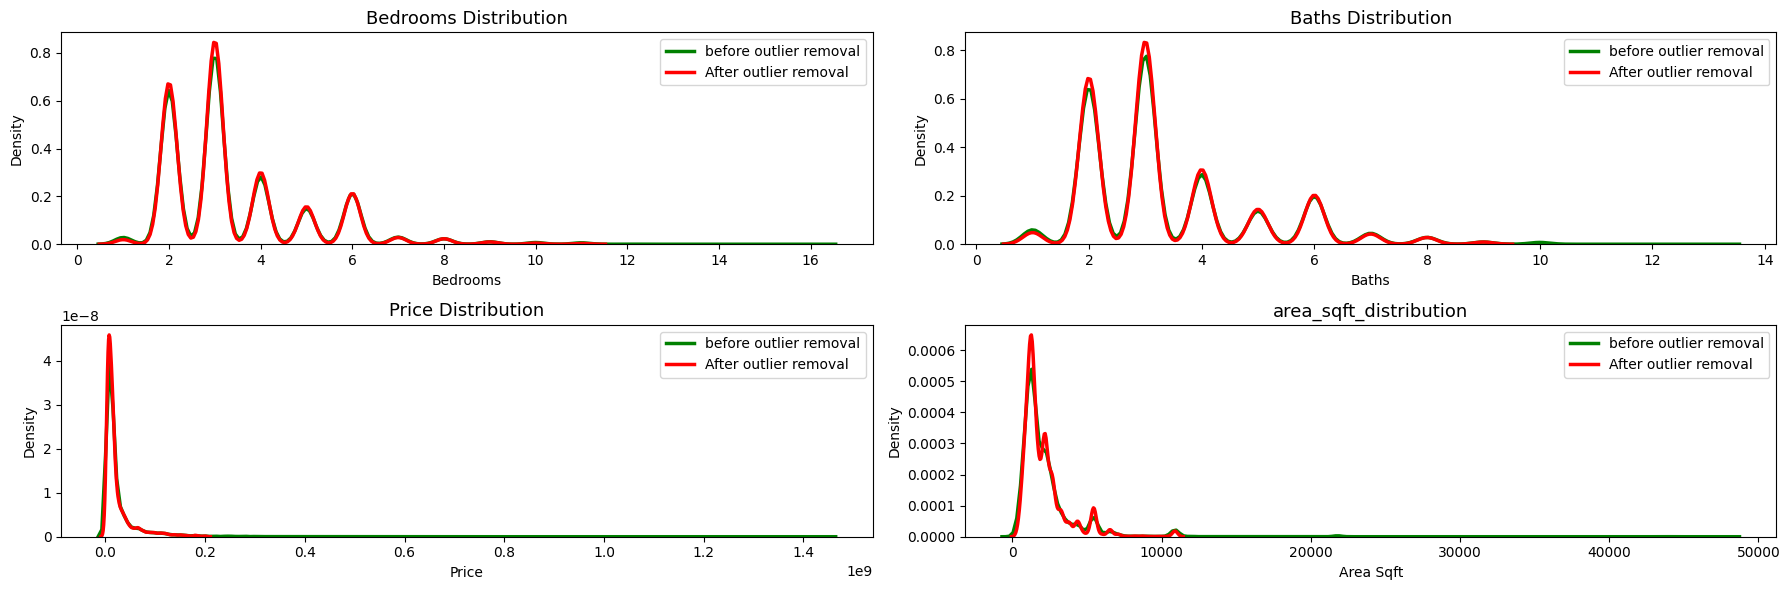

In [21]:
#check distirbution in the after outlier removal
plt.figure(figsize=(18, 6))

cols = ['bedrooms', 'baths', 'price','area_sqft']
titles = ['Bedrooms Distribution', 'Baths Distribution', 'Price Distribution','area_sqft_distribution']
colors = {'real_estate': 'green', 'real_estate_df': 'red'}

for i, col in enumerate(cols):
    plt.subplot(2, 2, i+1)
    
    # Plot KDE for real_estate
    sns.kdeplot(data=real_estate, x=col, color=colors['real_estate'], 
                linewidth=2.5, label='before outlier removal')
    
    # Plot KDE for real_estate_df
    sns.kdeplot(data=real_estate_df, x=col, color=colors['real_estate_df'], 
                linewidth=2.5, label='After outlier removal')
    
    plt.title(titles[i], fontsize=13)
    plt.xlabel(col.replace('_', ' ').title())
    plt.ylabel('Density')
    plt.legend()
    plt.tight_layout()
plt.savefig('../outputs/outlier_analysis.png', dpi=150, bbox_inches='tight')
plt.show()    

In [22]:
print(real_estate_df['price'].skew())
print(real_estate_df['bedrooms'].skew())
print(real_estate_df['baths'].skew())
print(real_estate_df['area_sqft'].skew())

2.860659977228228
1.3913806809929852
1.1864967370948951
2.5395647537248878


In [23]:
# Price per square foot
real_estate_df['price_per_sqft'] = real_estate_df['price'] / real_estate_df['area_sqft']

print("Price per sqft statistics:")
print(real_estate_df['price_per_sqft'].describe())

Price per sqft statistics:
count     45223.000000
mean       9114.648458
std        6060.169705
min         183.654729
25%        5072.368709
50%        7269.666361
75%       11256.257591
max      125219.133484
Name: price_per_sqft, dtype: float64


In [24]:
# ── Affordability Index ─────────────────────────────────────────────
INFLATION_MULTIPLIER    = round(CPI_2026 / CPI_2019, 4)  #2.431  
CUMULATIVE_INFLATION_PC = round(CPI_2026 - CPI_2019, 1)  #143.1 
AVG_ANNUAL_SALARY_2019  = AVG_MONTHLY_SALARY_2019 * 12   #264000  
AVG_ANNUAL_SALARY_2026  = AVG_MONTHLY_SALARY_2026 * 12  #516000

In [25]:
real_estate_df['affordability_years_2019'] = (
    real_estate_df['price'] / AVG_ANNUAL_SALARY_2019
)
real_estate_df['estimated_price_2026'] = (
    real_estate_df['price'] * INFLATION_MULTIPLIER
)
real_estate_df['affordability_years_2026'] = (
    real_estate_df['estimated_price_2026'] / AVG_ANNUAL_SALARY_2026
)
real_estate_df['affordability_change'] = (
    real_estate_df['affordability_years_2026']
    - real_estate_df['affordability_years_2019']
)
real_estate_df.rename(columns={'affordability_years_2019':'affordability_years'},inplace=True)

In [26]:
print(f"""
  2019 salary : PKR {AVG_MONTHLY_SALARY_2019:,}/month  (PBS PSLM FY2019)
  2026 salary : PKR {AVG_MONTHLY_SALARY_2026:,}/month  (Rozee.pk 2024 + SBP est)
  CPI 2026    : {CPI_2026} on 2019=100  (raw PBS = {CPI_RAW_2026} on 2015-16=100)
  Multiplier  : {INFLATION_MULTIPLIER}x
  Cum inf     : {CUMULATIVE_INFLATION_PC}%  
""")
 
_m19 = real_estate_df['affordability_years'].median()
_m26 = real_estate_df['affordability_years_2026'].median()
print(f"  Median affordability 2019 : {_m19:.1f} years")
print(f"  Median affordability 2026 : {_m26:.1f} years")
print(f"  Change                    : {_m26-_m19:+.1f} years")


  2019 salary : PKR 22,000/month  (PBS PSLM FY2019)
  2026 salary : PKR 43,000/month  (Rozee.pk 2024 + SBP est)
  CPI 2026    : 243.1 on 2019=100  (raw PBS = 282.45 on 2015-16=100)
  Multiplier  : 2.431x
  Cum inf     : 143.1%  

  Median affordability 2019 : 47.3 years
  Median affordability 2026 : 58.9 years
  Change                    : +11.5 years


In [27]:
# Market Tier Label
tier_map = {
    'DHA Defence':              'Elite',
    'Clifton':                  'Elite',
    'Old Clifton':              'Elite',
    'Bath Island':              'Elite',
    'Cantt':                    'Elite',
    'Bahria Town Karachi':      'Upper Middle',
    'Scheme 33':                'Upper Middle',
    'Navy Housing Scheme Karsaz': 'Upper Middle',
    'PECHS':                    'Upper Middle',
    'Gulshan-e-Iqbal Town':     'Middle Class',
    'Gulistan-e-Jauhar':        'Middle Class',
    'Federal B Area':           'Middle Class',
    'Saddar Town':              'Middle Class',
    'North Nazimabad':          'Middle Class',
    'Nazimabad':                'Middle Class',
    'Jamshed Town':             'Middle Class',
    'North Karachi':            'Middle Class',
    'Gadap Town':               'Affordable',
    'Malir':                    'Affordable',
    'Korangi':                  'Affordable',
    'Lyari':                    'Affordable',
    'Orangi Town':              'Affordable',
    'Baldia Town':              'Affordable',
    'Liaquatabad':              'Affordable',
}

real_estate_df['market_tier'] = real_estate_df['location'].map(tier_map)
real_estate_df['market_tier'] = real_estate_df['market_tier'].fillna('Other')

print("Market tier distribution:")
print(real_estate_df['market_tier'].value_counts())

Market tier distribution:
market_tier
Middle Class    16927
Upper Middle    10251
Elite            8133
Other            5130
Affordable       4782
Name: count, dtype: int64


In [28]:
# Price per Marla
real_estate_df['price_per_marla'] = real_estate_df['price'] / (real_estate_df['area_sqft'] / 272.25)
print("\nPrice per marla statistics:")
print(real_estate_df['price_per_marla'].describe())


Price per marla statistics:
count    4.522300e+04
mean     2.481463e+06
std      1.649881e+06
min      5.000000e+04
25%      1.380952e+06
50%      1.979167e+06
75%      3.064516e+06
max      3.409091e+07
Name: price_per_marla, dtype: float64


In [29]:
real_estate_df['date_added'] = pd.to_datetime(real_estate_df['date_added'],errors='coerce')
print(real_estate_df['date_added'].dtype)
print(real_estate_df['date_added'].head())
real_estate_df['Month_Year'] = ( real_estate_df['date_added'] .dt.to_period('M') .astype(str))

datetime64[us]
1   2019-07-18
2   2018-10-20
3   2019-03-10
4   2019-07-18
5   2019-06-20
Name: date_added, dtype: datetime64[us]


<h4 style="font-family: 'Arial';"><b>Key Observations:</b></h4>

<h4 style="font-family: 'Arial';color:green;"><b><i>Outlier Treatment:</i></b></h4>
<ul style="font-family: 'Arial'; color: green; font-size:16px;"><i>
<li><b>price and area_sqft:</b>percentile clipping:
Rows outside the 1st–99th percentile were removed for price and area. This cut extreme values without touching the bulk of the data. Price was trimmed to the range PKR 1.5M – 203M and area to 490 – 10,890 sqft. Price removal: 904 rows (1.9%). Area removal: 368 rows (0.8%).</li>  
<li><b>Bedrooms and baths — hard cap:</b>Properties with more than 11 bedrooms or more than 9 baths were dropped. These are almost certainly data entry errors reported from . Only 144 rows were removed, keeping the dataset clean without losing real listings. Final dataset: 45,223 rows. Total removed from original: 1,416 rows (3%)</li>  
<li><b>Skewness after cleaning:</b>Even after outlier removal, price and area are still right-skewed. This is normal for property markets — a few premium properties push the mean well above the median. Price skew: 2.86, Area skew: 2.54, Bedrooms skew: 1.39, Baths skew: 1.19.</li>
    
</ul></i> 

<h4 style="font-family: 'Arial';color:green;"><b><i>Engineered Features:</i></b></h4>    
<ul style="font-family: 'Arial'; color: green; font-size:16px;"><i>
<li><b>price_per_sqft:</b> Created as the primary comparison metric 
across areas. Raw price alone is misleading means a large cheap house 
can cost more than a small expensive flat. Price per sqft removes the size effect and allows fair area comparison. Median across all listings is PKR 7,270 per sqft.</li>
<li><b>affordability_years (2019 baseline):</b>Calculated as property price divided by the average annual Karachi salary in 2019, which was PKR 22,000/month — or PKR 264,000/year (source: PBS PSLM survey). This converts abstract PKR figures into something human: how many years of full salary does this property cost? The median across all listings is about 47 years, meaning the typical Karachi property cost 47 years of an average salary in 2019.</li>
<li><b>estimated_price_2026 and affordability_years_2026:</b>Property prices are inflation-adjusted to 2026 using a CPI multiplier of 2.43x, reflecting cumulative inflation of roughly 143% since 2019. Affordability is then recalculated using the 2026 average salary of PKR 43,000/month — PKR 516,000/year. This pair of columns lets us compare housing affordability across 7 years on the same scale. Median affordability in 2026 is about 59 years.</li> 
<li><b>affordability_change:</b>The difference between 2026 and 2019 affordability years for each property. A negative value means housing became more affordable; a positive value means it got harder to afford. The Median shift +11.6 years (worsened), , meaning the typical Karachi property
became harder to afford. This is because CPI inflation (2.431×) outpaced
salary growth (1.955×) — real purchasing power fell to 80.4 of its 2019 level.</li>    
<li><b>market_tier:</b> Areas grouped into Elite, Upper Middle, 
Middle Class, and Affordable tiers to enable structured comparison 
across Karachi's housing market segments.</li>
<li><b>month_year:</b>Extracted from date_added as a YYYY-MM string. This groups listings by month and lets us track listing volume trends over time. for example, spotting seasonal patterns, identifying which years had the most activity, or seeing how the market responded to economic events in Karachi.</li>    
<li><b>price_per_marla:</b> Added alongside price_per_sqft as 
Marla is the standard unit used in Pakistani real estate 
conversations and agent discussions.One Marla equals 272.25 sqft. Showing both units means the data speaks the local language and is immediately useful without manual conversion. Median is PKR 1.98M per Marla.</li> 
</ul></i>

In [30]:
real_estate_df.to_csv('../data/preprocessed/featured_engineering_listings.csv', index=False)
print("Exported for Power BI:", real_estate_df.shape)
print("Columns:", real_estate_df.columns.tolist())
print("Saved successfully.")

Exported for Power BI: (45223, 17)
Columns: ['property_type', 'price', 'location', 'latitude', 'longitude', 'baths', 'bedrooms', 'date_added', 'area_sqft', 'price_per_sqft', 'affordability_years', 'estimated_price_2026', 'affordability_years_2026', 'affordability_change', 'market_tier', 'price_per_marla', 'Month_Year']
Saved successfully.
